In [ ]:


import os
import random
import warnings

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

import matplotlib.pyplot as plt
import seaborn as sns


SEED = 42
np.random.seed(SEED)
random.seed(SEED)

CSV_PATH = "/content/1_2_3combined_csv.csv"

FEATURES = [
    "ACC ML [g]",
    "ACC AP [g]",
    "ACC SI [g]",
    "GYR ML [deg/s]",
    "GYR AP [deg/s]",
    "GYR SI [deg/s]",
]

LABEL = "Freezing event [flag]"
N_QUBITS = len(FEATURES)
TEST_SIZE = 0.20

MAX_TRAIN_QUANTUM = 500
MAX_TEST_QUANTUM = 1000

# SVM regularization parameter.
SVM_C = 1.0

=

print("=" * 70)
print("SOFTWARE VERSIONS")
print("=" * 70)
print("Python    :", __import__("sys").version)
print("PennyLane :", qml.__version__)
print("NumPy     :", np.__version__)
print("Quantum ML method: Quantum kernel + classical SVM")

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"Dataset was not found at:\n{CSV_PATH}\n"
        "Update CSV_PATH to your actual CSV location."
    )

df = pd.read_csv(CSV_PATH)

print("\n" + "=" * 70)
print("DATASET")
print("=" * 70)
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

for feature in FEATURES:
    if feature not in df.columns:
        raise ValueError(f"Feature '{feature}' was not found in the dataset.")

if LABEL not in df.columns:
    raise ValueError(f"Label '{LABEL}' was not found in the dataset.")

X = df[FEATURES].copy()
y = df[LABEL].copy()

X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

y = pd.to_numeric(y, errors="coerce")
valid_rows = y.notna()
X = X.loc[valid_rows]
y = y.loc[valid_rows].astype(int)

unique_labels = sorted(y.unique().tolist())
if not set(unique_labels).issubset({0, 1}):
    raise ValueError(f"Expected binary labels 0 and 1, found {unique_labels}")

print("\nClass distribution:")
print(y.value_counts().sort_index())

X_train, X_test, y_train, y_test = train_test_split(
    X.values.astype(np.float64),
    y.values.astype(np.int64),
    test_size=TEST_SIZE,
    stratify=y.values,
    random_state=SEED,
)

print("\n" + "=" * 70)
print("DATA SPLIT")
print("=" * 70)
print("Full training samples:", len(X_train))
print("Full testing samples :", len(X_test))


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_q = np.clip(X_train_scaled, -np.pi, np.pi)
X_test_q = np.clip(X_test_scaled, -np.pi, np.pi)



train_count = min(MAX_TRAIN_QUANTUM, len(X_train_q))
test_count = min(MAX_TEST_QUANTUM, len(X_test_q))

X_train_q, _, y_train_q, _ = train_test_split(
    X_train_q,
    y_train,
    train_size=train_count,
    stratify=y_train,
    random_state=SEED,
)

X_test_q, _, y_test_q, _ = train_test_split(
    X_test_q,
    y_test,
    train_size=test_count,
    stratify=y_test,
    random_state=SEED,
)

print("\nQuantum-kernel training samples:", len(X_train_q))
print("Quantum-kernel testing samples :", len(X_test_q))
print("Quantum training distribution:")
print(pd.Series(y_train_q).value_counts().sort_index())


# ============================================================
# 8. QUANTUM FIDELITY KERNEL
# ============================================================

try:
    qdev = qml.device("lightning.qubit", wires=N_QUBITS)
    qdevice_name = "lightning.qubit"
except Exception as exc:
    print("lightning.qubit unavailable; using default.qubit.")
    print("Reason:", exc)
    qdev = qml.device("default.qubit", wires=N_QUBITS)
    qdevice_name = "default.qubit"

print("\n" + "=" * 70)
print("QUANTUM FIDELITY KERNEL")
print("=" * 70)
print("Qubits:", N_QUBITS)
print("Device:", qdevice_name)


@qml.qnode(qdev)
def quantum_fidelity_kernel(x1, x2):
    """
    Return the squared overlap between two angle-encoded states.

    The circuit prepares the state for x1, applies the inverse encoding
    for x2, and measures the probability of returning to |000000>.
    The result is a kernel value in [0, 1].
    """
    qml.AngleEmbedding(
        x1,
        wires=range(N_QUBITS),
        rotation="Y",
    )
    qml.adjoint(qml.AngleEmbedding)(
        x2,
        wires=range(N_QUBITS),
        rotation="Y",
    )
    return qml.expval(
        qml.Projector(
            [0] * N_QUBITS,
            wires=range(N_QUBITS),
        )
    )


def compute_kernel_matrix(X_left, X_right=None):
    """Compute a quantum kernel matrix using explicit QNode evaluations."""
    if X_right is None:
        X_right = X_left

    kernel = np.empty((len(X_left), len(X_right)), dtype=np.float64)
    total = len(X_left) * len(X_right)
    completed = 0

    for i, x_left in enumerate(X_left):
        for j, x_right in enumerate(X_right):
            kernel[i, j] = float(quantum_fidelity_kernel(x_left, x_right))
            completed += 1

        if (i + 1) % 10 == 0 or i == len(X_left) - 1:
            print(
                f"Kernel progress: {completed}/{total} "
                f"({100.0 * completed / total:.1f}%)"
            )


    if X_right is X_left or (
        len(X_left) == len(X_right) and np.array_equal(X_left, X_right)
    ):
        np.fill_diagonal(kernel, 1.0)

    return kernel


print("\nComputing training quantum kernel matrix...")
K_train = compute_kernel_matrix(X_train_q)

print("\nComputing testing quantum kernel matrix...")
K_test = compute_kernel_matrix(X_test_q, X_train_q)

print("Training kernel shape:", K_train.shape)
print("Testing kernel shape :", K_test.shape)
print("Training kernel range:", K_train.min(), "to", K_train.max())
print("Testing kernel range :", K_test.min(), "to", K_test.max())



print("\n" + "=" * 70)
print("TRAINING CLASSICAL SVM ON QUANTUM KERNEL")
print("=" * 70)

svm_model = SVC(
    C=SVM_C,
    kernel="precomputed",
    class_weight="balanced",
    probability=False,
    random_state=SEED,
)

svm_model.fit(K_train, y_train_q)


decision_scores = svm_model.decision_function(K_test)
y_pred = svm_model.predict(K_test)



accuracy = accuracy_score(y_test_q, y_pred)
precision = precision_score(y_test_q, y_pred, zero_division=0)
recall = recall_score(y_test_q, y_pred, zero_division=0)
f1 = f1_score(y_test_q, y_pred, zero_division=0)
auc = roc_auc_score(y_test_q, decision_scores)

print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    y_test_q,
    y_pred,
    labels=[0, 1],
    target_names=["No Freezing", "Freezing"],
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test_q, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Freezing", "Freezing"],
    yticklabels=["No Freezing", "Freezing"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Quantum-Kernel SVM\nParkinson's Freezing of Gait")
plt.tight_layout()
plt.savefig("quantum_kernel_svm_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 6))
heatmap_size = min(100, len(K_train))
sns.heatmap(
    K_train[:heatmap_size, :heatmap_size],
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
)
plt.xlabel("Training samples")
plt.ylabel("Training samples")
plt.title("Quantum Fidelity Kernel Matrix")
plt.tight_layout()
plt.savefig("quantum_fidelity_kernel_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


MODEL_PATH = "traditional_quantum_kernel_svm.joblib"
SCALER_PATH = "traditional_quantum_ml_scaler.joblib"
TRAIN_FEATURES_PATH = "quantum_kernel_training_features.npy"

joblib.dump(svm_model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
np.save(TRAIN_FEATURES_PATH, X_train_q)

print("\nSaved files:")
print(" -", MODEL_PATH)
print(" -", SCALER_PATH)
print(" -", TRAIN_FEATURES_PATH)
print(" - quantum_kernel_svm_confusion_matrix.png")
print(" - quantum_fidelity_kernel_heatmap.png")


SOFTWARE VERSIONS
Python    : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PennyLane : 0.45.1
NumPy     : 2.1.3
Quantum ML method: Quantum kernel + classical SVM

DATASET
Dataset shape: (61440, 9)
Columns: ['User', 'Time [s]', 'ACC ML [g]', 'ACC AP [g]', 'ACC SI [g]', 'GYR ML [deg/s]', 'GYR AP [deg/s]', 'GYR SI [deg/s]', 'Freezing event [flag]']
   User  Time [s]  ACC ML [g]  ACC AP [g]  ACC SI [g]  GYR ML [deg/s]  \
0     1  0.007812    0.191745   -0.511756    1.014700      -10.448125   
1     1  0.015625    0.226322   -0.258745    1.084140       -1.247650   
2     1  0.023438    0.405319   -0.561918    0.915292       -3.488858   
3     1  0.031250    0.620089   -0.285977    0.975270        7.025583   
4     1  0.039062    0.488221   -1.063820    0.640557       -1.527005   

   GYR AP [deg/s]  GYR SI [deg/s]  Freezing event [flag]  
0       58.094807       29.161523                      0  
1       56.511776       35.680386                      0  
2       49.336805       38.986

In [2]:
pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 41.9 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


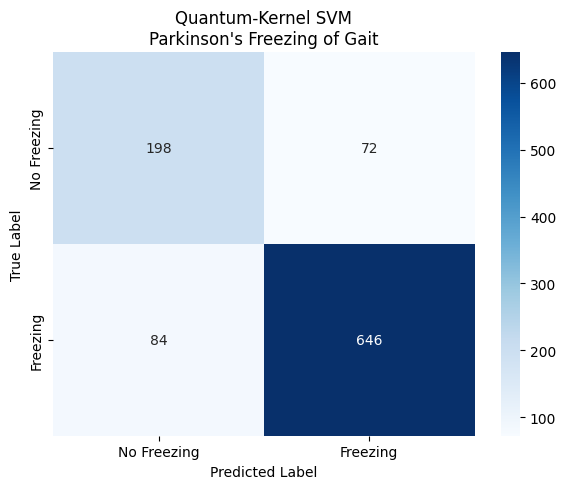

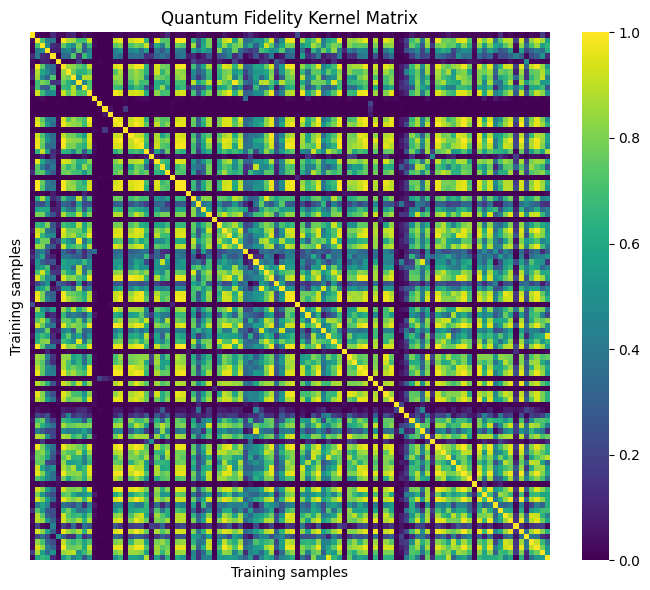

In [7]:
cm = confusion_matrix(y_test_q, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Freezing", "Freezing"],
    yticklabels=["No Freezing", "Freezing"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Quantum-Kernel SVM\nParkinson's Freezing of Gait")
plt.tight_layout()
plt.savefig("quantum_kernel_svm_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 12. QUANTUM KERNEL HEATMAP
# ============================================================

plt.figure(figsize=(7, 6))
heatmap_size = min(100, len(K_train))
sns.heatmap(
    K_train[:heatmap_size, :heatmap_size],
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
)
plt.xlabel("Training samples")
plt.ylabel("Training samples")
plt.title("Quantum Fidelity Kernel Matrix")
plt.tight_layout()
plt.savefig("quantum_fidelity_kernel_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [8]:

import joblib
import json
import numpy as np

MODEL_PATH = "traditional_quantum_kernel_svm.joblib"
SCALER_PATH = "traditional_quantum_ml_scaler.joblib"
TRAIN_FEATURES_PATH = "quantum_kernel_training_features.npy"
METADATA_PATH = "traditional_quantum_ml_metadata.json"

joblib.dump(svm_model, MODEL_PATH)

joblib.dump(scaler, SCALER_PATH)

np.save(TRAIN_FEATURES_PATH, X_train_q)

metadata = {
    "features": FEATURES,
    "label": LABEL,
    "n_qubits": N_QUBITS,
    "quantum_device": qdevice_name,
    "kernel_type": "quantum_fidelity_kernel",
    "classifier": "SVC with precomputed kernel",
    "svm_C": SVM_C,
    "training_samples": int(len(X_train_q)),
}

with open(METADATA_PATH, "w") as file:
    json.dump(metadata, file, indent=4)

print("\nTrained model saved successfully:")
print(f"- SVM model       : {MODEL_PATH}")
print(f"- Feature scaler  : {SCALER_PATH}")
print(f"- Training data   : {TRAIN_FEATURES_PATH}")
print(f"- Metadata        : {METADATA_PATH}")



Trained model saved successfully:
- SVM model       : traditional_quantum_kernel_svm.joblib
- Feature scaler  : traditional_quantum_ml_scaler.joblib
- Training data   : quantum_kernel_training_features.npy
- Metadata        : traditional_quantum_ml_metadata.json
